# TF-IDF + an SVM baseline on 20 Newsgroups

Non-LLM baseline: classify directly using a TF-IDF representation of the text.

### Prerequisites:

 - We will use [pandas](https://pandas.pydata.org/docs/) for data processing
 - We will use [scikit-learn](https://scikit-learn.org/stable/api/index.html) for the TF-IDF vectorizer and the an SVM classifier

Furthermore, we will perform our experiments on the [20 Newsgroups dataset](https://huggingface.co/datasets/SetFit/20_newsgroups).

In [1]:
%%capture
# install dependencies:
!pip install numpy matplotlib seaborn torch pandas scikit-learn crepes transformers sentence-transformers accelerate tqdm datasets

### Data processing

In [2]:
from datasets import load_dataset

train_data = load_dataset("SetFit/20_newsgroups", split="train")
test_data = load_dataset("SetFit/20_newsgroups", split="test")

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Repo card metadata block was not found. Setting CardData to empty.


Repo card metadata block was not found. Setting CardData to empty.


Train set size: 11314 examples
Test set size: 7532 examples


In [3]:
# convert datasets to dataframes:
train_df = train_data.to_pandas()
test_df = test_data.to_pandas()

# filter out empty texts:
train_df = train_df[train_df['text'].str.strip().astype(bool)]
test_df = test_df[test_df['text'].str.strip().astype(bool)]

train_df.sample()

,text,label,label_text
8415,You have missed something. There is a big dif...,14,sci.space


In [4]:
from sklearn.model_selection import train_test_split

# sample 2k training examples stratified by label:
train_df, _ = train_test_split(
    train_df, stratify=train_df["label"], train_size=2000, random_state=42
)

# sample 1k test examples stratified by label:
test_df, _ = train_test_split(
    test_df, stratify=test_df["label"], train_size=1000, random_state=42
)

print(f"Train subset size: {len(train_df)} examples")
print(f"Test subset size: {len(test_df)} examples")

Train subset size: 2000 examples
Test subset size: 1000 examples


We use the newsgroup topic (`label_text`) associated with each post `text` as the target category to predict:

In [5]:
# use the topic name as the target label:
train_df['label_name'] = train_df['label_text']
test_df['label_name'] = test_df['label_text']

In [6]:
# select input and label from data:
X_train = train_df['text'].to_numpy()
y_train = train_df['label_name'].to_numpy()

X_test = test_df['text'].to_numpy()
y_test = test_df['label_name'].to_numpy()

classes = set(y_train)
print('Classes: ', len(classes))

Classes:  20


### Results Handling Helper

In [7]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import json

def save_results(y_true, y_pred, classes, filename="results.json"):
    """
    Save classification metrics (report, accuracy, confusion matrix) to JSON.
    """
    report = classification_report(
        y_true, y_pred, labels=classes, zero_division=0, output_dict=True
    )
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    results = {
        "classification_report": report,
        "accuracy": accuracy,
        "confusion_matrix": cm.tolist(),
        "labels": classes
    }

    with open(filename, "w") as f:
        json.dump(results, f, indent=2)

    print(f"Results saved to: '{filename}'")

In [8]:
import json
import numpy as np

def save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="prompt_lengths.json"):
    """
    Save prompt, input, shots section lengths, and number of shots to a JSON file,
    including summary statistics.
    """
    stats = {
        "prompt_lengths": {
            "mean": float(np.mean(prompt_lengths)),
            "min": int(np.min(prompt_lengths)),
            "max": int(np.max(prompt_lengths)),
            "std": float(np.std(prompt_lengths)),
            "values": prompt_lengths
        },
        "input_lengths": {
            "mean": float(np.mean(input_lengths)),
            "min": int(np.min(input_lengths)),
            "max": int(np.max(input_lengths)),
            "std": float(np.std(input_lengths)),
            "values": input_lengths
        },
        "shots_lengths": {
            "mean": float(np.mean(shots_lengths)),
            "min": int(np.min(shots_lengths)),
            "max": int(np.max(shots_lengths)),
            "std": float(np.std(shots_lengths)),
            "values": shots_lengths
        },
        "num_shots": {
            "mean": float(np.mean(num_shots)),
            "min": int(np.min(num_shots)),
            "max": int(np.max(num_shots)),
            "std": float(np.std(num_shots)),
            "values": num_shots
        }
    }

    with open(filename, "w") as f:
        json.dump(stats, f, indent=2)

    print(f"Prompt length statistics saved to: '{filename}'")

### Linear SVM Classifier using TFIDF-Vectorizer

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline

tfidf_svm = make_pipeline(
    TfidfVectorizer(),
    LinearSVC()
)

tfidf_svm.fit(X_train, y_train)

predictions = tfidf_svm.predict(X_test)

Classification Report:
                           precision    recall  f1-score   support

      talk.religion.misc       0.39      0.32      0.35        34
  soc.religion.christian       0.56      0.75      0.64        52
               rec.autos       0.57      0.65      0.61        51
   comp.sys.mac.hardware       0.67      0.61      0.64        51
        rec.sport.hockey       0.80      0.81      0.80        53
               sci.space       0.61      0.69      0.65        52
      talk.politics.guns       0.60      0.62      0.61        48
         rec.motorcycles       0.68      0.64      0.66        53
           comp.graphics       0.59      0.70      0.64        53
   talk.politics.mideast       0.81      0.69      0.74        51
      rec.sport.baseball       0.83      0.73      0.78        52
            misc.forsale       0.69      0.73      0.71        52
             alt.atheism       0.45      0.40      0.42        43
      talk.politics.misc       0.43      0.37      

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5]),
 [Text(0, 0.5, 'talk.religion.misc'),
  Text(0, 1.5, 'soc.religion.christian'),
  Text(0, 2.5, 'rec.autos'),
  Text(0, 3.5, 'comp.sys.mac.hardware'),
  Text(0, 4.5, 'rec.sport.hockey'),
  Text(0, 5.5, 'sci.space'),
  Text(0, 6.5, 'talk.politics.guns'),
  Text(0, 7.5, 'rec.motorcycles'),
  Text(0, 8.5, 'comp.graphics'),
  Text(0, 9.5, 'talk.politics.mideast'),
  Text(0, 10.5, 'rec.sport.baseball'),
  Text(0, 11.5, 'misc.forsale'),
  Text(0, 12.5, 'alt.atheism'),
  Text(0, 13.5, 'talk.politics.misc'),
  Text(0, 14.5, 'sci.med'),
  Text(0, 15.5, 'sci.crypt'),
  Text(0, 16.5, 'sci.electronics'),
  Text(0, 17.5, 'comp.windows.x'),
  Text(0, 18.5, 'comp.os.ms-windows.misc'),
  Text(0, 19.5, 'comp.sys.ibm.pc.hardware')])

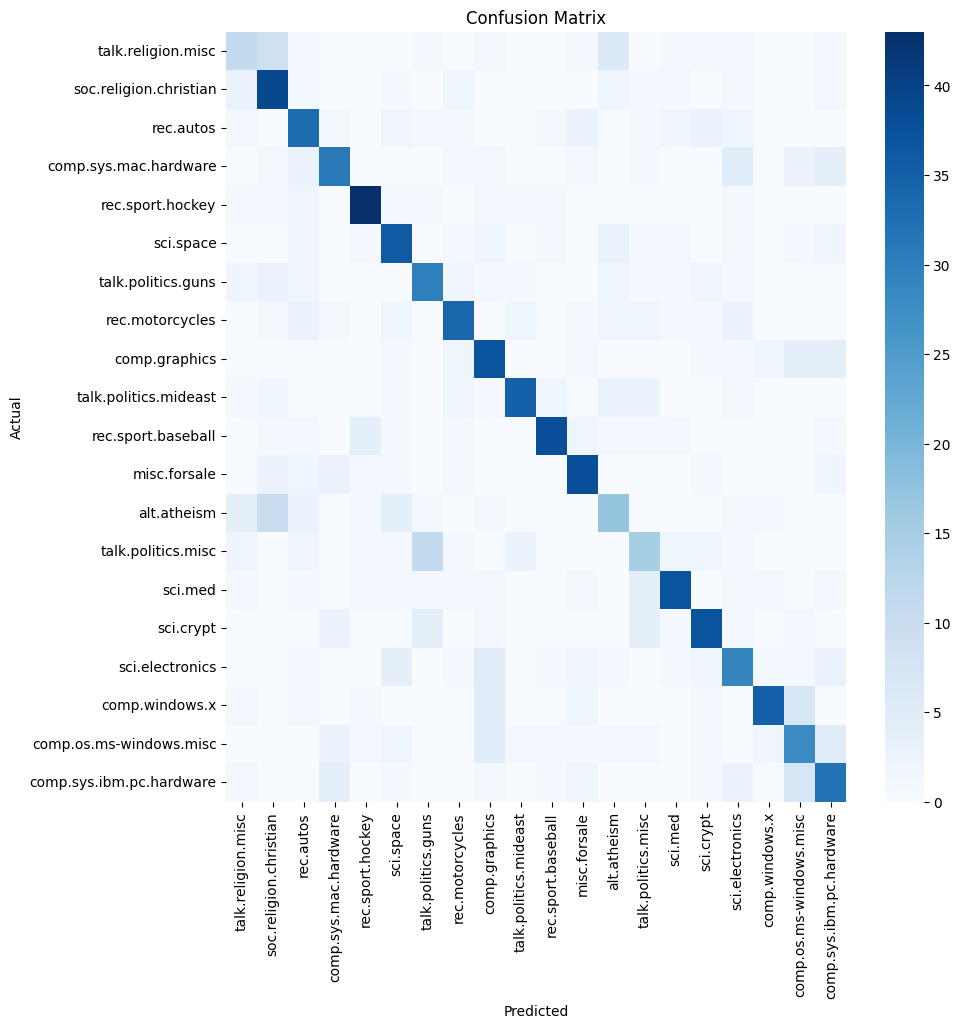

In [10]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Classification Report:\n", classification_report(y_test, predictions, labels=list(classes), zero_division=0))
print("Accuracy:", accuracy_score(y_test, predictions))

# Plot confusion matrix
cm = confusion_matrix(y_test, predictions, labels=list(classes))
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=list(classes), yticklabels=list(classes))
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.xticks(rotation=90); plt.yticks(rotation=0)

In [11]:
save_results(y_test, predictions, list(classes), filename="/home/v25/ippa6201/cicle-evaluation/20-newsgroups/results/predictions/20-newsgroups-tfidf-svm-2.0k-samples.json")

Results saved to: '/home/v25/ippa6201/cicle-evaluation/20-newsgroups/results/predictions/20-newsgroups-tfidf-svm-2.0k-samples.json'
